In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import zipfile
import io

backtest_returns = pd.read_csv("../data/processed/backtest_returns.csv", index_col=0, parse_dates=True)

zip_path = "../data/raw/F-F_Research_Data_Factors_daily_CSV.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    file_name = z.namelist()[0]
    raw_text = z.read(file_name).decode("latin1")

lines = raw_text.splitlines()

header_index = None
for i, line in enumerate(lines):
    if "Mkt-RF" in line and "SMB" in line and "HML" in line and "RF" in line:
        header_index = i
        break

ff_data = pd.read_csv(io.StringIO("\n".join(lines[header_index:])))

date_col = ff_data.columns[0]
ff_data = ff_data[ff_data[date_col].astype(str).str.match(r"^\d{8}$")]

ff_data[date_col] = pd.to_datetime(ff_data[date_col], format="%Y%m%d")
ff_data = ff_data.set_index(date_col)

ff_data = ff_data[["Mkt-RF", "SMB", "HML", "RF"]].astype(float) / 100

ff_data.head()

,Mkt-RF,SMB,HML,RF
Unnamed: 0,,,,
1926-07-01,0.0009,-0.0025,-0.0027,0.0001
1926-07-02,0.0045,-0.0033,-0.0006,0.0001
1926-07-06,0.0017,0.0030,-0.0039,0.0001
1926-07-07,0.0009,-0.0058,0.0002,0.0001
1926-07-08,0.0022,-0.0038,0.0019,0.0001


In [2]:
merged_data = backtest_returns.join(ff_data, how="inner")

merged_data.head()

,Equal Weight,Minimum Variance,Maximum Sharpe,Risk Parity,SPY Benchmark,Mkt-RF,SMB,HML,RF
2016-01-05,0.002666,-0.000240,-0.001736,0.001293,0.001691,0.0013,-0.0018,0.0000,0.0
2016-01-06,-0.004106,0.002448,-0.009611,0.000425,-0.012614,-0.0134,-0.0013,0.0001,0.0
2016-01-07,-0.015195,-0.006126,-0.031331,-0.009636,-0.023992,-0.0244,-0.0029,0.0008,0.0
2016-01-08,-0.008812,-0.004806,-0.008110,-0.006158,-0.010977,-0.0111,-0.0049,-0.0003,0.0
2016-01-11,-0.001462,-0.006157,0.003078,-0.003878,0.000990,-0.0006,-0.0064,0.0040,0.0


In [3]:
merged_data.shape

(2499, 9)

In [4]:
factor_results = {}

for strategy in backtest_returns.columns:
    y = merged_data[strategy] - merged_data["RF"]
    X = merged_data[["Mkt-RF", "SMB", "HML"]]
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit()
    factor_results[strategy] = model
    
    print("=" * 80)
    print(strategy)
    print(model.summary())

Equal Weight
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.872
Model:                            OLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                     5660.
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        14:29:47   Log-Likelihood:                 10936.
No. Observations:                2499   AIC:                        -2.186e+04
Df Residuals:                    2495   BIC:                        -2.184e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.859e-05    6.1e-05     -0

In [5]:
factor_summary = pd.DataFrame()

for strategy, model in factor_results.items():
    factor_summary.loc[strategy, "Alpha"] = model.params["const"]
    factor_summary.loc[strategy, "Market Beta"] = model.params["Mkt-RF"]
    factor_summary.loc[strategy, "SMB Beta"] = model.params["SMB"]
    factor_summary.loc[strategy, "HML Beta"] = model.params["HML"]
    factor_summary.loc[strategy, "R-squared"] = model.rsquared

factor_summary

,Alpha,Market Beta,SMB Beta,HML Beta,R-squared
Equal Weight,-0.000049,0.650783,0.138111,-0.014405,0.871884
Minimum Variance,0.000034,0.292095,0.024903,-0.109906,0.356045
Maximum Sharpe,0.000012,0.474716,0.051190,-0.227403,0.419400
Risk Parity,0.000037,0.467197,0.135921,-0.046441,0.660378
SPY Benchmark,-0.000072,0.981781,-0.120942,0.019419,0.991622


In [6]:
factor_summary.to_csv("../data/processed/factor_regression_summary.csv")

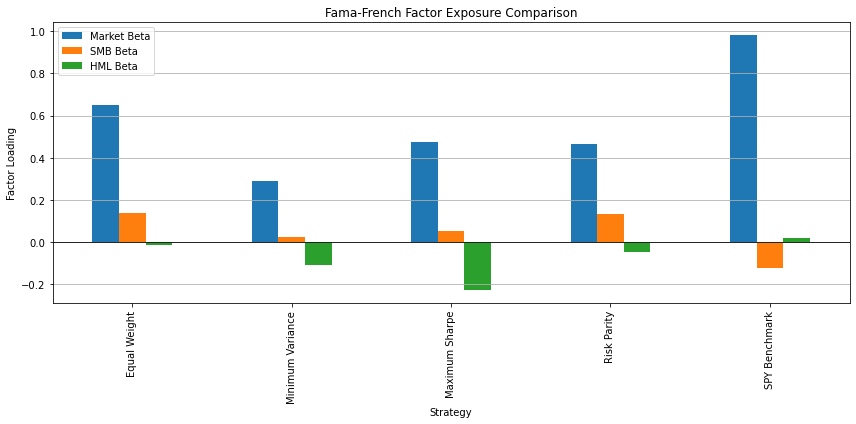

In [7]:
factor_exposures = factor_summary[["Market Beta", "SMB Beta", "HML Beta"]]

factor_exposures.plot(kind="bar", figsize=(12, 6))

plt.title("Fama-French Factor Exposure Comparison")
plt.xlabel("Strategy")
plt.ylabel("Factor Loading")
plt.axhline(0, color="black", linewidth=0.8)
plt.grid(axis="y")
plt.tight_layout()

plt.savefig("../figures/factor_exposure_comparison.png", dpi=300)
plt.show()

## Factor Regression Interpretation

The Fama-French three-factor regression shows that the SPY benchmark is almost entirely explained by market exposure, with a market beta close to one and an R-squared above 0.99. This is consistent with SPY's role as a broad U.S. equity market benchmark.

The optimized portfolios have lower market betas than SPY, reflecting their diversified exposure to non-equity assets such as long-term Treasury bonds and gold. The minimum variance portfolio has the lowest market beta and the lowest R-squared, suggesting that its returns are less dependent on traditional equity risk factors. The risk parity portfolio maintains moderate market exposure while improving diversification across asset classes.

The maximum Sharpe portfolio shows a negative HML loading, which is consistent with its allocation toward growth-oriented assets such as QQQ. Across strategies, alpha estimates are close to zero, so the results should be interpreted as evidence of factor exposure differences rather than evidence of persistent abnormal returns.